In [1]:
# Import important libraries for data analysis and machine learning

import pandas as pd          # Used for data manipulation
import numpy as np           # Used for numerical operations

import matplotlib.pyplot as plt   # Used for plotting graphs
import seaborn as sns             # Used for advanced visualizations

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Set default visualization style
sns.set_style("whitegrid")

In [4]:
# Load the feature engineered dataset

df = pd.read_csv(r"D:\Downloads\feature_engineered_dataset.csv")

# Display first 5 rows of dataset
df.head()

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
0,3,6.0,77,STAFFORD ST,2,6000.0,1092.0,1.0,WRIGHT,2024-07-01 00:00:00+00:00,...,187200,1,10,5,False,12.464587,2024,7,237.179487,1.383547
1,3,3.0,73,STAFFORD ST,2,6000.0,936.0,1.0,SANTANA,2022-04-26 00:00:00+00:00,...,192300,1,10,5,False,12.245298,2022,4,222.222222,1.081643
2,3,6.0,61,STAFFORD ST,2,6000.0,1111.0,1.0,MARTINEZ,2023-12-22 00:00:00+00:00,...,148400,1,10,5,False,11.736077,2023,12,112.511251,0.842318
3,3,6.0,211,NEWINGTON AVE,2,5040.0,1684.0,1.0,CAHUANA FLORES,2021-01-11 00:00:00+00:00,...,197900,1,10,5,False,12.083911,2021,1,105.106888,0.894391
4,3,3.0,18,BRISTOL ST,2,6000.0,900.0,1.0,NEGRON,2021-09-21 00:00:00+00:00,...,170700,1,10,5,False,12.144203,2021,9,208.888889,1.101347


In [ ]:
# Display structure of dataset
# Shows number of columns, data types, and non-null values

df.info()

In [5]:
# Check if dataset contains missing values

df.isnull().sum()

xrCompositeLandUseID       0
xrBuildingTypeID           0
LocationStartNumber        0
StreetNameAndWay           0
xrPrimaryNeighborhoodID    0
LandSF                     0
TotalFinishedArea          0
LivingUnits                0
OwnerLastName              0
SaleDate                   0
SalePrice                  0
TotalAppraisedValue        0
xrSalesValidityID          0
xrDeedID                   0
AssrLandUse                0
WasZeroPrice               0
LogSalePrice               0
SaleYear                   0
SaleMonth                  0
PricePerSqft               0
AppraisalRatio             0
dtype: int64

In [7]:
# Remove columns that are not useful for prediction
# These are mostly text fields that do not affect price modeling

df = df.drop(columns=[
    'StreetNameAndWay',
    'OwnerLastName'
], errors='ignore')

# Convert SaleDate column into datetime format
df['SaleDate'] = pd.to_datetime(df['SaleDate'])

# Display updated dataset
df.head()

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,SaleDate,SalePrice,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
0,3,6.0,77,2,6000.0,1092.0,1.0,2024-07-01 00:00:00+00:00,259000.0,187200,1,10,5,False,12.464587,2024,7,237.179487,1.383547
1,3,3.0,73,2,6000.0,936.0,1.0,2022-04-26 00:00:00+00:00,208000.0,192300,1,10,5,False,12.245298,2022,4,222.222222,1.081643
2,3,6.0,61,2,6000.0,1111.0,1.0,2023-12-22 00:00:00+00:00,125000.0,148400,1,10,5,False,11.736077,2023,12,112.511251,0.842318
3,3,6.0,211,2,5040.0,1684.0,1.0,2021-01-11 00:00:00+00:00,177000.0,197900,1,10,5,False,12.083911,2021,1,105.106888,0.894391
4,3,3.0,18,2,6000.0,900.0,1.0,2021-09-21 00:00:00+00:00,188000.0,170700,1,10,5,False,12.144203,2021,9,208.888889,1.101347


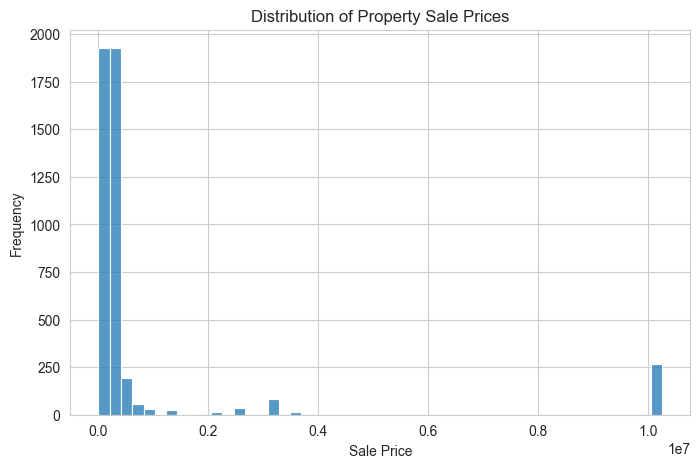

In [8]:
# Plot histogram to understand how sale prices are distributed

plt.figure(figsize=(8,5))

sns.histplot(df['SalePrice'], bins=50)

plt.title("Distribution of Property Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

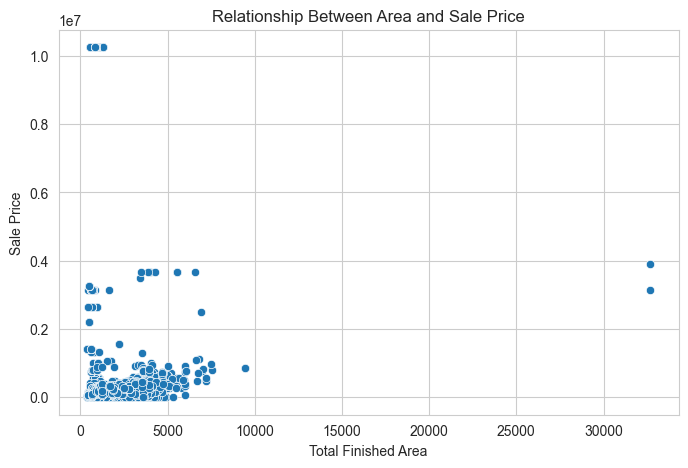

In [9]:
# Scatter plot to see relationship between property area and price

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['TotalFinishedArea'],
    y=df['SalePrice']
)

plt.title("Relationship Between Area and Sale Price")
plt.xlabel("Total Finished Area")
plt.ylabel("Sale Price")

plt.show()

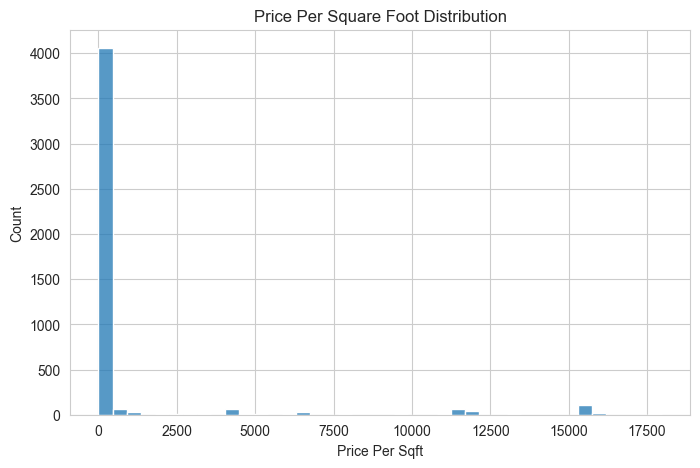

In [10]:
# Histogram to understand price per square foot distribution

plt.figure(figsize=(8,5))

sns.histplot(df['PricePerSqft'], bins=40)

plt.title("Price Per Square Foot Distribution")
plt.xlabel("Price Per Sqft")

plt.show()

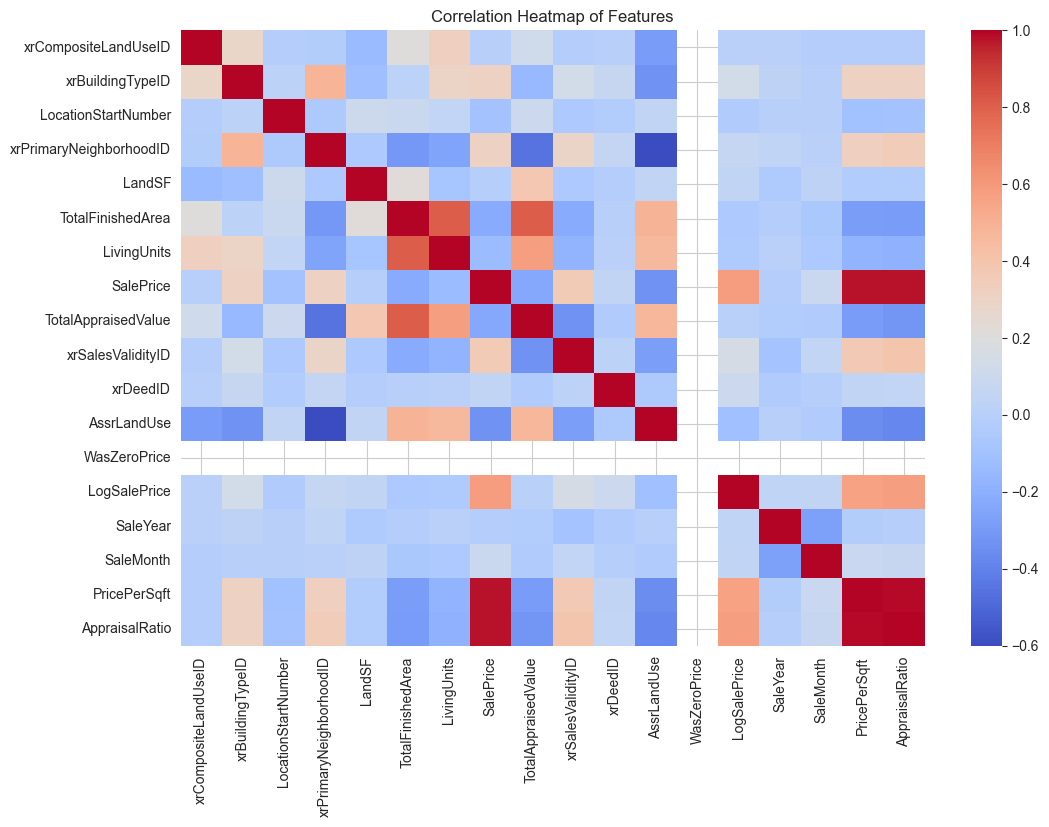

In [11]:
# Correlation heatmap helps understand relationships between variables

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Features")

plt.show()

In [12]:
# Separate input features (X) and target variable (y)

# Features used for prediction
features = df.drop(columns=[
    'SalePrice',
    'SaleDate'
])

# Target variable
target = df['SalePrice']

In [13]:
# Split dataset into training and testing sets
# 80% data used for training
# 20% used for testing

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (3652, 17)
Testing Data Shape: (914, 17)


In [15]:
import numpy as np

# Remove infinity values
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill missing values
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

In [16]:
# Create Linear Regression model

lr_model = LinearRegression()

# Train the model using training data
lr_model.fit(X_train, y_train)

# Predict house prices using testing data
pred_lr = lr_model.predict(X_test)

In [17]:
# Random Forest is usually better for complex datasets

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Predict prices
pred_rf = rf_model.predict(X_test)

In [18]:
# Evaluate Linear Regression performance

mae_lr = mean_absolute_error(y_test, pred_lr)
mse_lr = mean_squared_error(y_test, pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression Results")

print("Mean Absolute Error:", mae_lr)
print("Root Mean Squared Error:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
Mean Absolute Error: 166900.8253963753
Root Mean Squared Error: 396870.302152757
R2 Score: 0.9683347597047364


In [19]:
# Evaluate Random Forest model

mae_rf = mean_absolute_error(y_test, pred_rf)
mse_rf = mean_squared_error(y_test, pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest Results")

print("Mean Absolute Error:", mae_rf)
print("Root Mean Squared Error:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
Mean Absolute Error: 3726.1951979759315
Root Mean Squared Error: 89304.05175290984
R2 Score: 0.9983966515685663


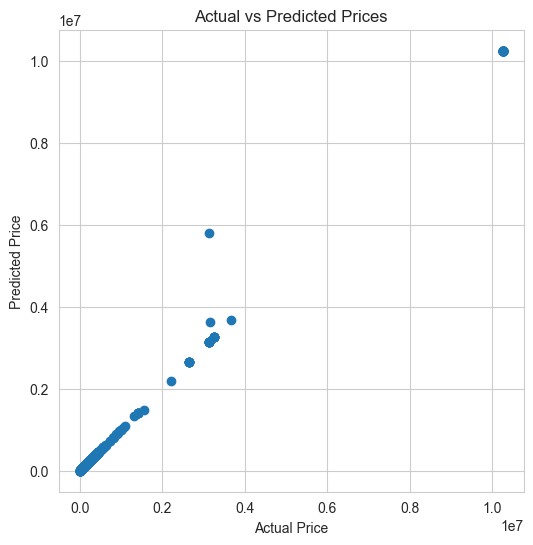

In [20]:
# Scatter plot comparing actual prices vs predicted prices

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

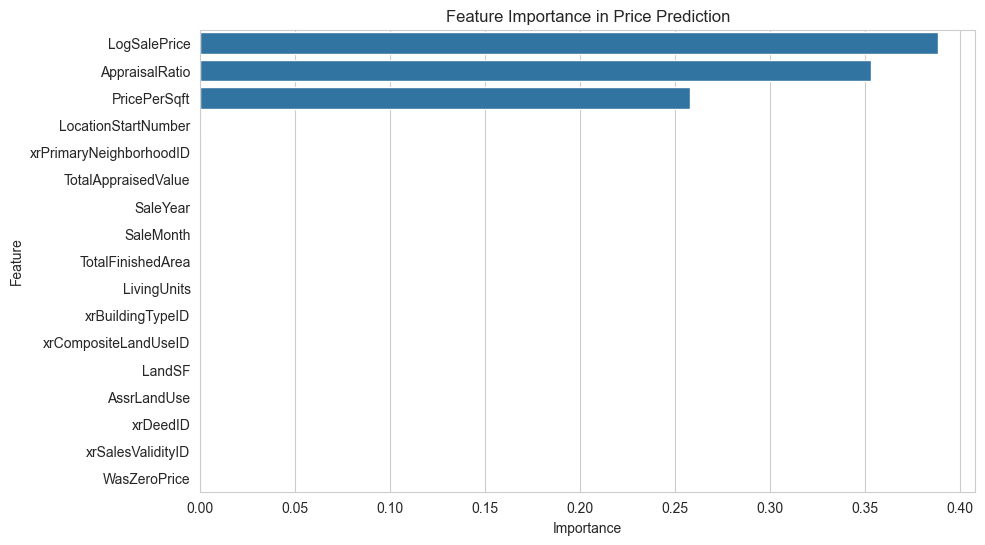

In [21]:
# Feature importance shows which variables affect price the most

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features.columns,
    'Importance': importances
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance in Price Prediction")

plt.show()

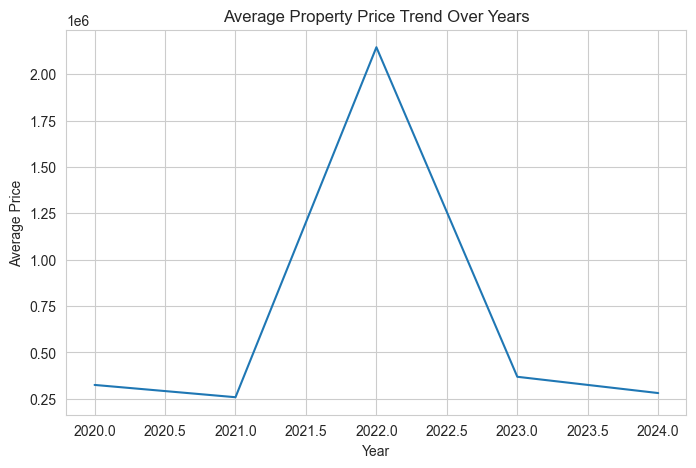

In [22]:
# Analyze how prices change over years

df['SaleYear'] = pd.to_numeric(df['SaleYear'])

price_trend = df.groupby('SaleYear')['SalePrice'].mean()

plt.figure(figsize=(8,5))

price_trend.plot()

plt.title("Average Property Price Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Price")

plt.show()

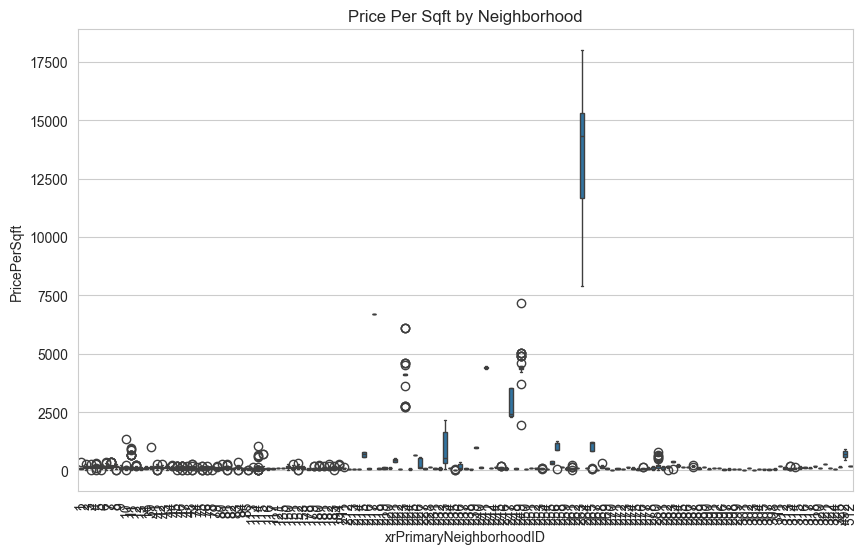

In [23]:
# Boxplot to compare property prices across neighborhoods

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['xrPrimaryNeighborhoodID'],
    y=df['PricePerSqft']
)

plt.xticks(rotation=90)

plt.title("Price Per Sqft by Neighborhood")

plt.show()

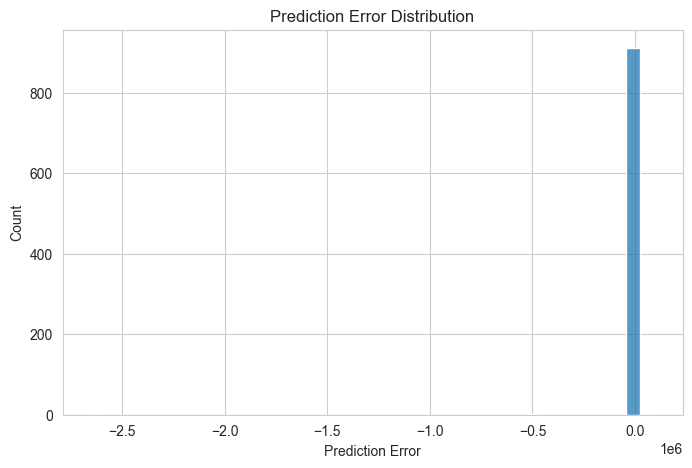

In [24]:
# Analyze how prediction errors are distributed

errors = y_test - pred_rf

plt.figure(figsize=(8,5))

sns.histplot(errors, bins=40)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.show()

In [25]:
# Export the DataFrame to CSV
df.to_csv('modeled_dataset.csv', index=False)